In [ ]:
import torch
print(torch.__version__)            
print(torch.cuda.is_available())    
print(torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

2.11.0+cu128
True
NVIDIA RTX PRO 1000 Blackwell Generation Laptop GPU


In [ ]:
import pandas as pd

from torch import nn
from transformers import AutoTokenizer, DistilBertModel
from torch.utils.data import Dataset

import json

First merge the datasets

In [ ]:
df = pd.read_csv('data/dataset.csv')
df.head()

,Unnamed: 0,label_tec,label_subtec,tec_name,sentence
0,0,T1003,T1003.008,/etc/passwd and /etc/shadow,Adversaries may attempt to dump the contents o...
1,1,T1003,T1003.008,/etc/passwd and /etc/shadow,Most modern Linux operating systems use a comb...
2,2,T1003,T1003.008,/etc/passwd and /etc/shadow,"By default, /etc/shadow is only readable by th..."
3,3,T1003,T1003.008,/etc/passwd and /etc/shadow,"The Linux utility, unshadow, can be used to co..."
4,4,T1557,T1557.002,ARP Cache Poisoning,Adversaries may poison Address Resolution Prot...


In [ ]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df.rename(columns={'label_tec': 'attack_type', 'label_subtec': 'attack_subtype', 'tec_name': 'attack_name'}, inplace=True)
df.head()

,attack_type,attack_subtype,attack_name,sentence
0,T1003,T1003.008,/etc/passwd and /etc/shadow,Adversaries may attempt to dump the contents o...
1,T1003,T1003.008,/etc/passwd and /etc/shadow,Most modern Linux operating systems use a comb...
2,T1003,T1003.008,/etc/passwd and /etc/shadow,"By default, /etc/shadow is only readable by th..."
3,T1003,T1003.008,/etc/passwd and /etc/shadow,"The Linux utility, unshadow, can be used to co..."
4,T1557,T1557.002,ARP Cache Poisoning,Adversaries may poison Address Resolution Prot...


In [ ]:
json_data = json.load(open('data/single_label.json'))
json_data = pd.DataFrame(json_data)
json_data.rename(columns={'label': 'attack_type', 'text': 'sentence'}, inplace=True)
json_data.drop(columns=['doc_title'], inplace=True)
json_data.head()

,sentence,attack_type
0,This file extracts credentials from LSASS simi...,T1003.001
1,It calls OpenProcess on lsass.exe with access ...,T1003.001
2,It spreads to Microsoft Windows machines using...,T1210
3,SMB exploitation via EternalBlue,T1210
4,SMBv1 Exploitation via EternalBlue,T1210


In [ ]:
has_sub = json_data['attack_type'].str.contains('.', regex=False)
json_data['attack_subtype'] = json_data['attack_type'].where(has_sub)  
json_data['attack_type'] = json_data['attack_type'].str.split('.', n=1).str[0]  


In [ ]:
df = pd.concat([df, json_data])
df.head()

,attack_type,attack_subtype,attack_name,sentence
0,T1003,T1003.008,/etc/passwd and /etc/shadow,Adversaries may attempt to dump the contents o...
1,T1003,T1003.008,/etc/passwd and /etc/shadow,Most modern Linux operating systems use a comb...
2,T1003,T1003.008,/etc/passwd and /etc/shadow,"By default, /etc/shadow is only readable by th..."
3,T1003,T1003.008,/etc/passwd and /etc/shadow,"The Linux utility, unshadow, can be used to co..."
4,T1557,T1557.002,ARP Cache Poisoning,Adversaries may poison Address Resolution Prot...


<Axes: xlabel='attack_type'>

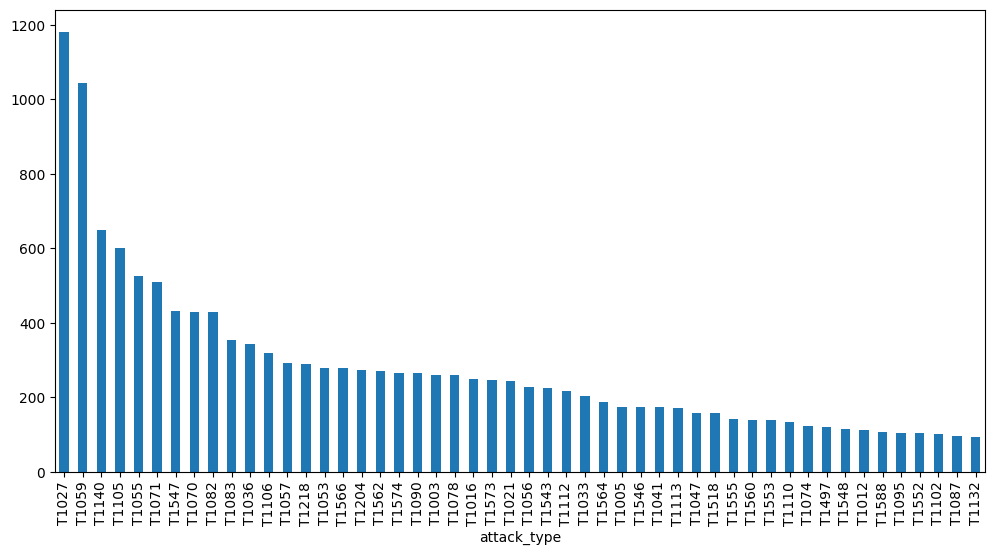

In [ ]:
attack_count = df['attack_type'].value_counts()[:50]
attack_count.plot(kind='bar', figsize=(12, 6))

In [ ]:
print("Total number of samples:", len(df))
print("Number of unique attack types:", df['attack_type'].nunique())

Total number of samples: 18034
Number of unique attack types: 188


In [ ]:
attack_to_idx = {attack: i for i, attack in enumerate(df['attack_type'].unique())}

df['label'] = df['attack_type'].map(attack_to_idx)
df.drop(columns=['attack_type', 'attack_subtype', 'attack_name'], inplace=True)

Lets build the model

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

In [27]:
max_length = train_df['sentence'].apply(lambda x: len(x.split())).max() * 2

In [30]:
class TextDataset(Dataset):

    def __init__(self, dataframe):
        self.data = dataframe
        self.tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-cased")

    def __getitem__(self, index):
        row = self.data.iloc[index]
        text = row['sentence']
        inputs = self.tokenizer(text, return_tensors="pt", padding="max_length", truncation=True)
        if 'label' in row:
            target = row['label']
        else:
            target = -1

        return {
            'input_ids': inputs['input_ids'].squeeze(),
            'attention_mask': inputs['attention_mask'].squeeze(),
            'targets': target,
        }
    
    def __len__(self):
        return len(self.data)

In [31]:
train = TextDataset(train_df)

test_labels = test_df['label'].values
test = TextDataset(test_df.drop(columns=['label']))

In [32]:
class mitreClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-cased")
        self.layer_1 = nn.Linear(768, 256)
        self.activation_1 = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.layer_2 = nn.Linear(256, 200)
        self.activation_2 = nn.ReLU()
        self.dropout_2 = nn.Dropout(0.3)
        self.layer_3 = nn.Linear(200, 200)
        self.activation_3 = nn.ReLU()
        self.dropout_3 = nn.Dropout(0.3)
        self.classifier = nn.Linear(200, 188)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        cls_output = outputs.last_hidden_state[:, 0, :]
        x = self.layer_1(cls_output)
        x = self.activation_1(x)
        x = self.dropout(x)
        x = self.layer_2(x)
        x = self.activation_2(x)
        x = self.dropout_2(x)
        x = self.layer_3(x)
        x = self.activation_3(x)
        x = self.dropout_3(x)
        x = self.classifier(x)

        return x
        

In [33]:
from tqdm import tqdm
from torch.utils.data import DataLoader
import torch.optim as optim

model = mitreClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5)


def train_single_epoch(network: nn.Module, data: Dataset) -> nn.Module:
    network.train()

    dataloader = DataLoader(data, batch_size=8, shuffle=True)

    total_loss = 0.0

    for batch in tqdm(dataloader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        targets = batch['targets'].long().to(device)

        optimizer.zero_grad()

        outputs = network(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(dataloader)
    print(f'Average training loss: {average_loss:.4f}')

    return model

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [34]:
epochs = 5

for epoch in range(epochs):
    print(f'Epoch {epoch + 1}/{epochs}')
    model = train_single_epoch(model, train)

Epoch 1/5


100%|██████████| 1804/1804 [08:05<00:00,  3.72it/s]


Average training loss: 4.3994
Epoch 2/5


100%|██████████| 1804/1804 [08:07<00:00,  3.70it/s]


Average training loss: 3.3105
Epoch 3/5


...

Average training loss: 2.6044
Epoch 4/5


100%|██████████| 1804/1804 [08:15<00:00,  3.64it/s]


Average training loss: 2.1394
Epoch 5/5


100%|██████████| 1804/1804 [08:20<00:00,  3.60it/s]

Average training loss: 1.8116


In [35]:
torch.save(model.state_dict(), "./mitre_classifier.pt")

In [36]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(network: nn.Module, data: Dataset, y_true: list) -> None:
    network.eval()

    dataloader = DataLoader(data, batch_size=8, shuffle=False)

    all_predictions = []
    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = network(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )

            predictions = torch.argmax(outputs, dim=1)
            all_predictions.extend(predictions.cpu().numpy())

    print(classification_report(y_true, all_predictions))
    print(confusion_matrix(y_true, all_predictions))

In [37]:
evaluate_model(model, test, test_labels)

100%|██████████| 451/451 [00:43<00:00, 10.48it/s]

              precision    recall  f1-score   support

           0       0.71      0.77      0.74        52
           1       0.00      0.00      0.00         8
           2       0.00      0.00      0.00        11
           3       0.58      0.65      0.61        23
           4       0.50      0.27      0.35        15
           5       0.31      0.43      0.36        35
           6       0.00      0.00      0.00         1
           7       0.57      0.21      0.31        19
           8       0.00      0.00      0.00        10
           9       0.00      0.00      0.00        15
          10       0.00      0.00      0.00         4
          11       0.75      0.81      0.78        86
          12       0.00      0.00      0.00        11
          13       0.81      0.89      0.85       209
          14       0.00      0.00      0.00        13
          15       0.00      0.00      0.00        10
          16       0.77      0.90      0.83       102
          17       0.00    


c:\Users\tim_a\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tim_a\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tim_a\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
